In [ ]:
# | default_exp dmd_data

# Build the Yin-Yang Scaling Dataset

> We build a dataset from a scaled network

#### Imports and Setup

In [ ]:
from ast import literal_eval
from natsort import natsorted
import matplotlib.pyplot as plt
import matrepr
import numpy as np
from matrepr import mprint
from safetensors.torch import load_model, save_file

import seaborn as sns
from learningdynamics.datasets import YinYangBinaryDataset
from learningdynamics.models import MLP
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from collections import OrderedDict

In [ ]:
# | export
import torch
import einops

In [ ]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"

%matplotlib inline

In [ ]:
LAYER_START = 1

#### Load Dataset

In [ ]:
NUM_SAMPLES = 20_000
NUM_TRAJECTORIES = NUM_SAMPLES // 2  # Number of trajectories
MAGIC_NUMBER = -1

In [ ]:
# Build dataset
dataset = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)

In [ ]:
# Randomly pick indices for training dataset
train_indices = np.random.choice(
    dataset.features.shape[0], size=NUM_TRAJECTORIES, replace=False
)

# Randomly pick indices for test dataset
test_indices = np.random.choice(
    np.setdiff1d(np.arange(NUM_SAMPLES), train_indices),
    size=int(NUM_SAMPLES - NUM_TRAJECTORIES),
    replace=False,
)

In [ ]:
print("Train Indices")
mprint(train_indices)
print()
print("Test Indices")
mprint(test_indices)

Train Indices
<length=10000, 10000 'int64' elements, array>
[6788, 4894, 1.835e+04, 1.573e+04, 1.179e+04, ..., 4789, 132, 8368, 4044, 6655]

Test Indices
<length=10000, 10000 'int64' elements, array>
[1.923e+04, 1.683e+04, 1.306e+04, 1.665e+04, ..., 1164, 2857, 1.739e+04, 1922]


#### Load Original Model

In [ ]:
# Load model
file_path = "../saved_weights/yinyang_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")
model.eval()

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=4, bias=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=3, bias=True)
    (7): ReLU()
    (8): Linear(in_features=3, out_features=2, bias=True)
  )
)

In [ ]:
_ = model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.9888499975204468


#### Load Scaled Model

In [ ]:
# Load model
file_path = f"../saved_weights/yinyang_start{LAYER_START}_scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(scaled_model, file_path, device="cuda:0")
scaled_model.eval()

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
    (7): ReLU()
    (8): Linear(in_features=8, out_features=8, bias=True)
    (9): ReLU()
    (10): Linear(in_features=8, out_features=8, bias=True)
    (11): ReLU()
    (12): Linear(in_features=8, out_features=8, bias=True)
    (13): ReLU()
    (14): Linear(in_features=8, out_features=8, bias=True)
    (15): ReLU()
    (16): Linear(in_features=8, out_features=8, bias=True)
    (17): ReLU()
    (18): Linear(in_features=8, out_features=8, bias=True)
    (19): ReLU()
    (20): Linear(in_features=8, out_features=8, bias=True)
    (21): ReLU()
    (22): Linear(in_features=8, out_features=6, bias=True)
    (23): ReLU()
    (24): Linear(in_features=6, out_features=4, bias=True)
    (25)

In [ ]:
_ = scaled_model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.9889500141143799


In [ ]:
LAYER_START = literal_eval(metadata["layer_start"])
NUM_STATES = literal_eval(metadata["layer_in_out"])
NUM_ITERATIONS = literal_eval(metadata["added_layers"]) + 2

LAYERS = [model.features[i] for i in (range(LAYER_START, LAYER_START + 3, 2))]
SCALED_LAYERS = [
    scaled_model.features[i]
    for i in (range(LAYER_START, LAYER_START + (NUM_ITERATIONS) * 2, 2))
]

#### Get activations

In [ ]:
hooks = []

# Dictionary to store activations
activation_dict = {}
scaled_activation_dict = {}

# Register the hooks
for idx, layer in enumerate(LAYERS):
    hooks.append(
        layer.register_forward_hook(getActivation(f"layer_{idx}", activation_dict))
    )

for idx, scaled_layer in enumerate(SCALED_LAYERS):
    hooks.append(
        scaled_layer.register_forward_hook(
            getActivation(f"scaled_layer_{idx}", scaled_activation_dict)
        )
    )

_ = model(dataset.features)
_ = scaled_model(dataset.features)

# Remove hook
for hook in hooks:
    hook.remove()

In [ ]:
def collect_timestep_tensor(dict, shuffle=False, magic_number=MAGIC_NUMBER):
    # sorted_dict = OrderedDict(natsorted(dict.items()))
    sorted_dict = dict
    values = list(sorted_dict.values())

    for i, v in enumerate(values):
        if v.shape[-1] != NUM_STATES:
            temp = torch.full((v.shape[0], NUM_STATES), magic_number)
            temp[:, : v.shape[-1]] = v
            values[i] = temp

    values_tensor = torch.stack(values)
    if shuffle:
        idx = torch.randperm(values_tensor.shape[1])
        values_tensor = values_tensor[:, idx, :]
    return values_tensor

#### Visualizing Trajectory

In [ ]:
SAMPLE = 0
PLOT_NUM_STATES = 4

In [ ]:
t = np.linspace(0, 1, 2)
states = collect_timestep_tensor(activation_dict)[:, SAMPLE, :].T

ts = np.linspace(0, 1, NUM_ITERATIONS)
scaled_states = collect_timestep_tensor(scaled_activation_dict)[:, SAMPLE, :].T

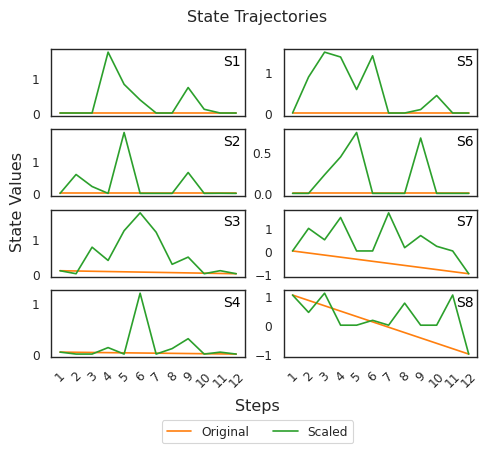

In [ ]:
sns.set_context("paper")
sns.set_style('white')

fig, axs = plt.subplots(
    PLOT_NUM_STATES, 2, sharex=True, tight_layout=False, figsize=(5.5, 1 * PLOT_NUM_STATES)
)

# Plotting states
for state_idx in range(0, PLOT_NUM_STATES):
    axs[state_idx, 0].plot(t, states[state_idx, :], "-", color="tab:orange", label="Original")
    axs[state_idx, 0].plot(ts, scaled_states[state_idx, :], "-", color="tab:green", label="Scaled")
    axs[state_idx, 1].plot(t, states[-PLOT_NUM_STATES + state_idx, :], "-", color="tab:orange", label="Original")
    axs[state_idx, 1].plot(ts, scaled_states[-PLOT_NUM_STATES + state_idx, :], "-", color="tab:green", label="Scaled")

    # Adding a counter at the top right of each subplot
    axs[state_idx, 0].text(0.98, 0.93, f"S{state_idx+1}", transform=axs[state_idx, 0].transAxes,
                           ha='right', va='top', fontsize=10, color='black')
    axs[state_idx, 1].text(0.98, 0.93, f"S{state_idx+1+PLOT_NUM_STATES}", transform=axs[state_idx, 1].transAxes,
                           ha='right', va='top', fontsize=10, color='black')


# Setting x-ticks and labels for the last subplot
axs[-1, 0].set_xticks(ts)
axs[-1, 0].set_xticklabels(range(1, NUM_ITERATIONS + 1), rotation=45)
axs[-1, 1].set_xticks(ts)
axs[-1, 1].set_xticklabels(range(1, NUM_ITERATIONS + 1), rotation=45)

# Adding legends outside the plots
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.12))

# Adding global titles and adjusting spacing
fig.suptitle('State Trajectories')
fig.supxlabel("Steps", y=-0.03)
fig.supylabel("State Values", x=0.05)

# Adjust layout to make space for the global titles and legends
plt.savefig('yinyang_states.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
SAMPLE = 0
PLOT_NUM_STATES = 4

In [ ]:
t = np.linspace(0, 1, 2)
states = collect_timestep_tensor(activation_dict, magic_number=MAGIC_NUMBER)[:, SAMPLE, :].T

ts = np.linspace(0, 1, NUM_ITERATIONS)
scaled_states = collect_timestep_tensor(scaled_activation_dict, magic_number=MAGIC_NUMBER)[:, SAMPLE, :].T

In [ ]:
metadata_dict = {
    "num_states": metadata["layer_in_out"],
    "num_trajectories": str(NUM_TRAJECTORIES),
    "num_iterations": str(NUM_ITERATIONS),
    "layer_start": metadata["layer_start"],
    "num_usable_states": str(scaled_model.features[LAYER_START + (NUM_ITERATIONS) * 2 - 3].out_features)
}

save_file(
    {
        "train_states": collect_timestep_tensor(scaled_activation_dict, magic_number=MAGIC_NUMBER)[
            :, train_indices, :
        ].contiguous(),
        "test_states": collect_timestep_tensor(scaled_activation_dict, shuffle=True, magic_number=MAGIC_NUMBER)[
            :, test_indices, :
        ].contiguous(),
    },
    f"../saved_weights/yinyang_start{LAYER_START}_states.safetensors",
    metadata=metadata_dict,
)

#### Reshaping dataset

In [ ]:
# | export
def reshape_interleave_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (i t)")

In [ ]:
# | export
def reshape_interleave_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (s t) i")

In [ ]:
# | export
def reshape_append_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (t i)")

In [ ]:
# | export
def reshape_append_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (t s) i")